# **Business Problem**

Healthcare costs can vary substantially between individuals based on demographic, health, healthcare-utilization and financial characteristics. The objective of this project is to develop a Linear Regression model that predicts annual medical charges based on these available characteristics.

## Objective

Build and evaluate a supervised machine-learning regression model and use it to estimate medical charges for a hypothetical individual.

**Load and understand the data**



In [30]:
#import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
df= pd.read_csv("/content/new_insurance_data (1) (1).csv")
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


# **EDA**

In [32]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [33]:
df.shape

(1338, 13)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

Insights:-
1. 13 columns and a data set of 1338 rows
2. 3 columns(sex, smoker and region) have object data type.
3. null values in some of the columns

In [35]:
#Data quality check

df.isnull().sum()


,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df. nunique()

,0
age,47
sex,2
bmi,547
children,6
smoker,2
Claim_Amount,1324
past_consultations,39
num_of_steps,1335
Hospital_expenditure,1334
NUmber_of_past_hospitalizations,4


Insights:-
1.Null values in all the float dtypes.
2. 0 duplicate values

considering it is insurance related data set so we will not drop the null values even though they are less then 3% so we will either use mean value of mdeian value.

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1329.0,3.931001e+01,1.403482e+01,1.800000e+01,2.700000e+01,3.900000e+01,5.100000e+01,6.400000e+01
bmi,1335.0,3.066511e+01,6.101690e+00,1.596000e+01,2.630250e+01,3.040000e+01,3.468750e+01,5.313000e+01
children,1333.0,1.090773e+00,1.201856e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,5.000000e+00
Claim_Amount,1324.0,3.336133e+04,1.561729e+04,1.920136e+03,2.076886e+04,3.370031e+04,4.505233e+04,7.727799e+04
past_consultations,1332.0,1.521622e+01,7.467723e+00,1.000000e+00,9.000000e+00,1.500000e+01,2.000000e+01,4.000000e+01
num_of_steps,1335.0,9.100047e+05,9.188612e+04,6.954300e+05,8.471995e+05,9.143000e+05,9.716840e+05,1.107872e+06
Hospital_expenditure,1334.0,1.584179e+07,2.669305e+07,2.945253e+04,4.077633e+06,7.490337e+06,1.084082e+07,2.616317e+08
NUmber_of_past_hospitalizations,1336.0,1.060629e+00,5.335831e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
Anual_Salary,1332.0,3.696849e+08,5.668843e+08,2.747072e+06,7.701932e+07,1.419361e+08,3.243499e+08,4.117197e+09
charges,1338.0,1.327042e+04,1.211001e+04,1.121874e+03,4.740287e+03,9.382033e+03,1.663991e+04,6.377043e+04


Insights:-
1. Age is relatively evenly distributed around the center, with customers ranging from 18 to 64 years and a mean age of approximately 39 years.
2. very high difference between min and max value of hospital expenditure with std of 26M and highest being 261M so it would be cheked for outliers.
3. Annual salary is also right skewed with lot of variance in mean and median.

Apart from 2-3 columns rest all seem to have outliers, so we will check for outliers later on and Null values will be filled with median.


In [39]:
#considering we will be using target variable as charges so lets understand the target variable
df["charges"].describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


# **Insights:-**

1.mean= 13270
2.median= 9382
3.Charges could be  right skewed because of some expenses



In [41]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [42]:
#let us edit the null values with the median

for i in df.columns:
  if (df[i].dtype != "object"):
    df[i]= df[i].fillna(df[i]. median())


In [43]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


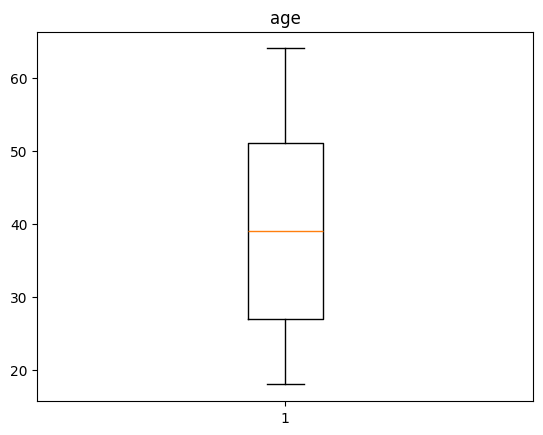

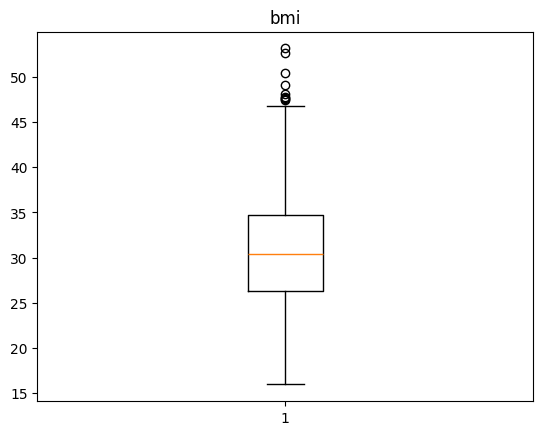

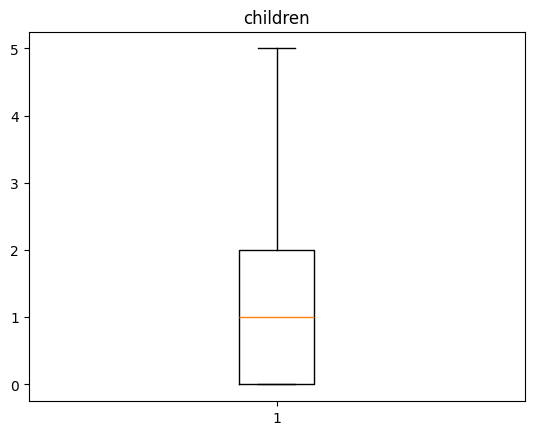

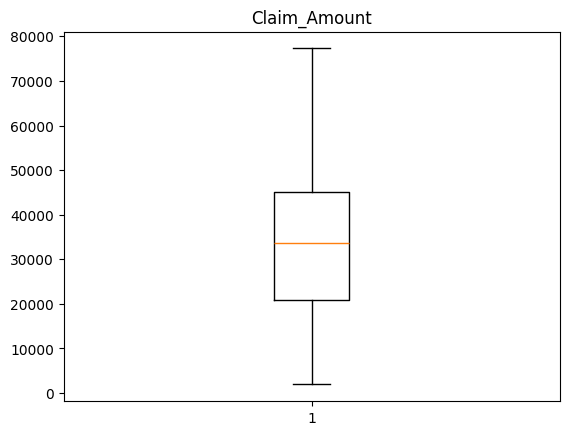

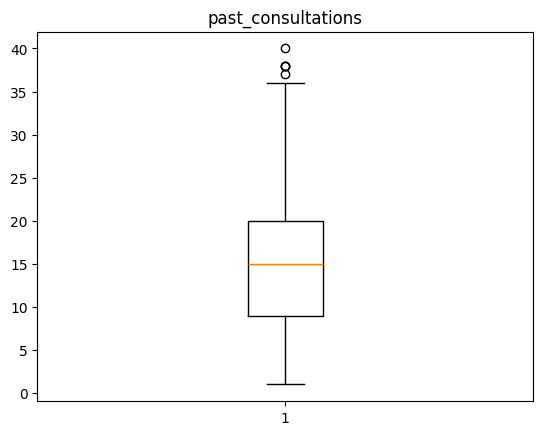

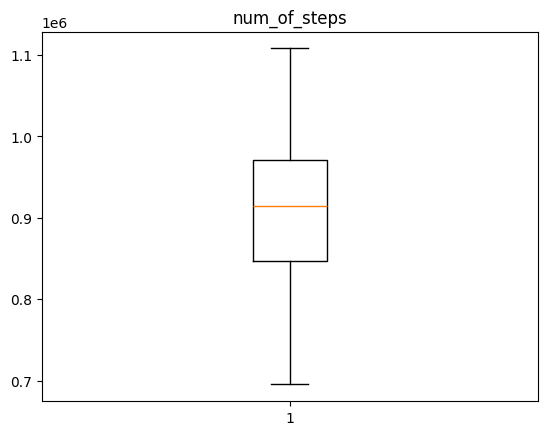

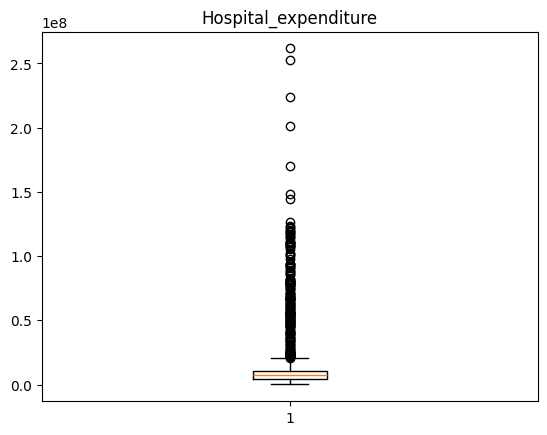

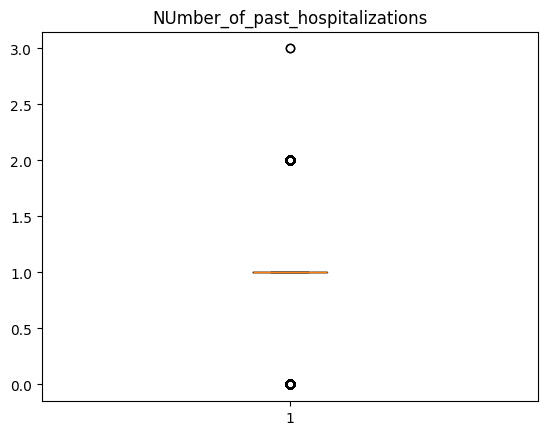

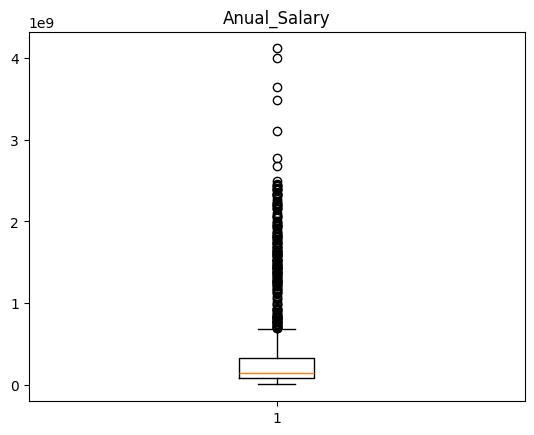

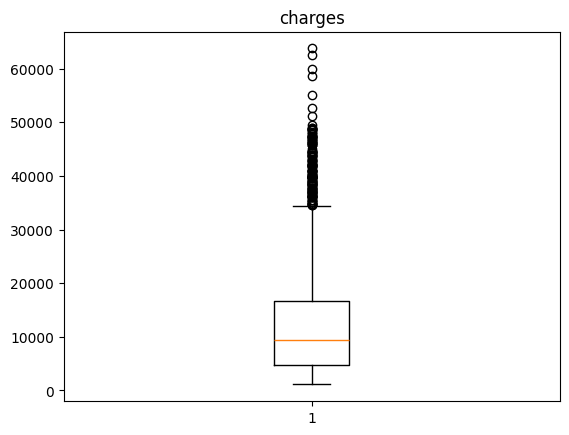

In [44]:
#Now let us use box plot and check for outliers in all the columns

for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [46]:
#identified outliers as per box plot

outliers = ["bmi","past_consultations","Hospital_expenditure","Anual_Salary"]

In [47]:
#We will use IQR to remove the outliers here

for i in outliers:
  q1= df[i].quantile(0.25)
  q3= df[i].quantile(0.75)
  IQR= q3-q1

  LB= q1-1.5*IQR
  UB= q3+1.5*IQR
  df= df[(df[i]>= LB) & (df[i]<= UB)]

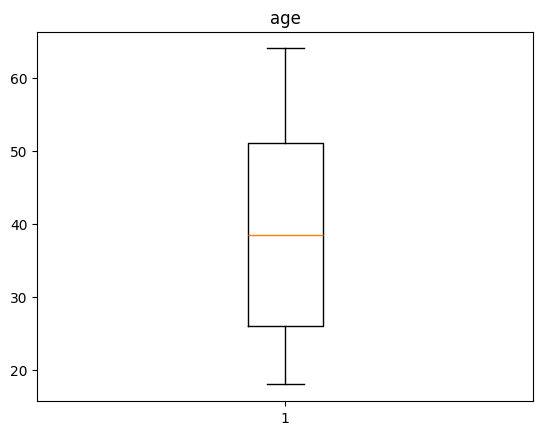

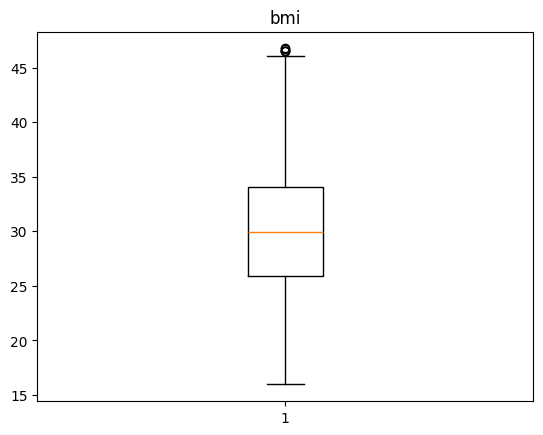

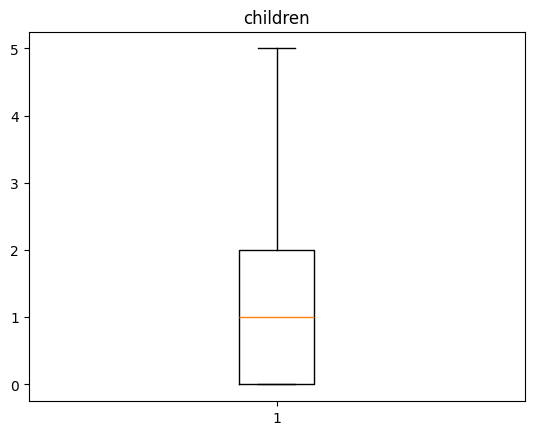

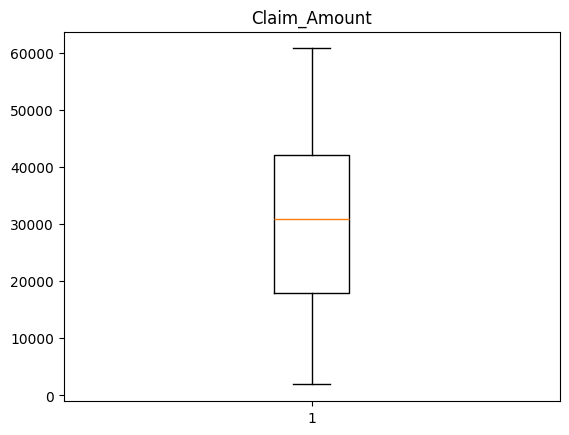

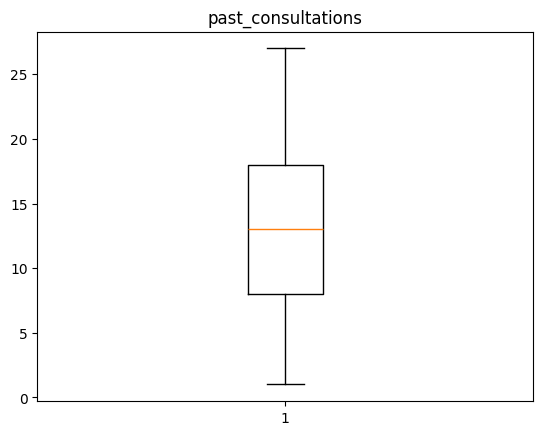

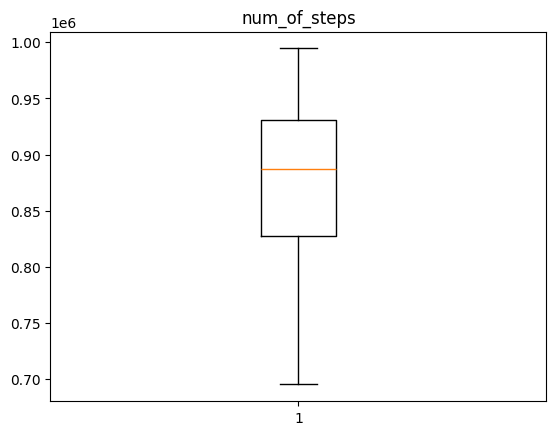

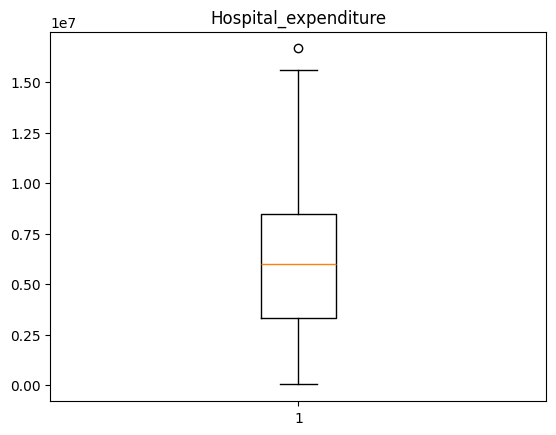

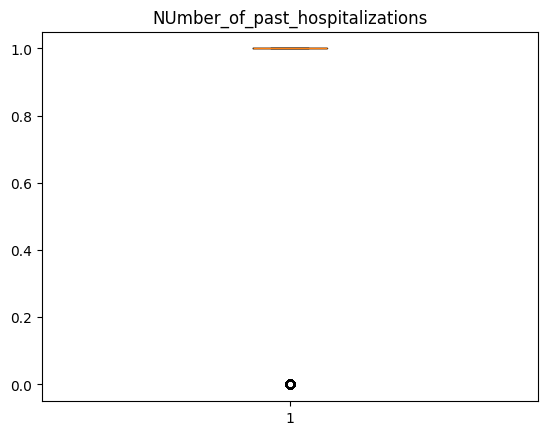

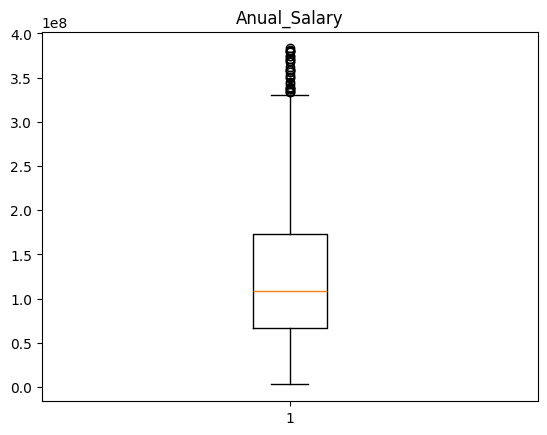

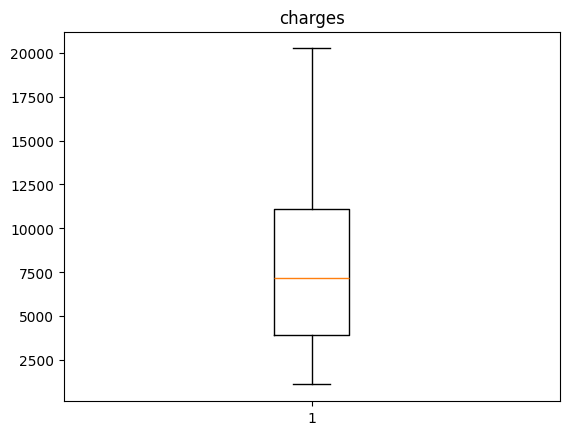

In [48]:
for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [50]:
#Now we will move on to Encoding to convert object dtype to int data type using label encoder

from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()



In [54]:
for i in df.columns:
  if(df[i].dtype== "object"):
    df[i]= le.fit_transform(df[i])   #fit understands the pattern and transform will convert the dtype: object to int

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1030 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1030 non-null   float64
 1   sex                              1030 non-null   int64  
 2   bmi                              1030 non-null   float64
 3   children                         1030 non-null   float64
 4   smoker                           1030 non-null   int64  
 5   Claim_Amount                     1030 non-null   float64
 6   past_consultations               1030 non-null   float64
 7   num_of_steps                     1030 non-null   float64
 8   Hospital_expenditure             1030 non-null   float64
 9   NUmber_of_past_hospitalizations  1030 non-null   float64
 10  Anual_Salary                     1030 non-null   float64
 11  region                           1030 non-null   int64  
 12  charges                  

In [ ]:
#Now our data is clean so we will move on to model building
# As our data has continous data for charges wchich needs to be predicted so it is a linear regression problem

In [ ]:
#Model building?

# import libraries
# split the data into independent(x) and the dependent(y)
# split the data into training and the testing part
# train the model
# test the model
# evaluate the model

In [56]:
x= df.drop("charges", axis= 1)
x  #All the columns except charges will be or Independent variable

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,1.419361e+08,0


In [58]:
y= df["charges"]
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1046,19107.77960
1048,19199.94400
1050,19350.36890
1062,19798.05455


In [61]:
#import Libraries and split the data into 80:20

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)


In [64]:
#check for test and training data
print('training data:', x_train)
print("test data:", x_test)

training data:        age  sex     bmi  children  smoker  Claim_Amount  past_consultations  \
1001  27.0    0  24.750       0.0       1  53835.714590                13.0   
509   46.0    1  22.300       0.0       0  39421.715810                11.0   
336   35.0    1  27.610       1.0       0  45580.280500                15.0   
854   60.0    1  25.740       0.0       0  10462.197210                15.0   
296   32.0    0  29.735       0.0       0  16081.646280                10.0   
...    ...  ...     ...       ...     ...           ...                 ...   
88    20.0    1  33.000       1.0       0   9408.348963                14.0   
332   30.0    0  22.895       1.0       0  32439.939850                11.0   
468   36.0    1  28.595       3.0       0  38533.729650                 4.0   
122   18.0    0  40.185       0.0       0  45623.681360                18.0   
866   59.0    1  27.500       1.0       0  22670.053110                20.0   

      num_of_steps  Hospital_expendi

In [66]:
#Build the model-Linear regression

from sklearn.linear_model import LinearRegression

model= LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [69]:
#testing the model by making it predict the data

y_pred= model. predict(x_test)
y_pred

array([ 1.53396788e+03,  1.43839745e+03,  2.71814085e+03,  1.90970173e+03,
        1.40262549e+04,  1.89452465e+04,  1.16026832e+04,  3.73549860e+03,
        4.10862902e+03,  8.17100120e+03,  1.27528240e+04,  8.40734417e+03,
        9.23740368e+02,  2.80267155e+03,  6.59778366e+03,  7.99085768e+03,
        1.16795958e+04,  8.89740695e+03,  1.07738897e+04,  6.08970414e+03,
        7.69998293e+03,  5.71419310e+03,  5.17194249e+03,  8.33032468e+03,
        5.32186767e+03,  4.77147113e+03,  9.14472765e+03,  1.36124538e+04,
        7.10425889e+03,  7.99627908e+03,  5.94957226e+03,  7.46318887e+03,
        1.06011121e+04,  5.86423932e+03,  5.61897971e+03,  8.46499803e+02,
        4.32645200e+03,  1.39290998e+04,  8.82665593e+03,  4.45204564e+03,
        9.14000912e+03,  9.77441776e+03, -1.48180765e+03,  8.67638395e+03,
        3.46361886e+03,  3.61675826e+03,  5.34035508e+03,  9.77268888e+03,
        1.17828770e+04,  1.06097414e+04,  1.24696750e+04,  9.77189189e+03,
        1.27006777e+04,  

In [70]:
y_pred.shape

(206,)

In [72]:
#let's heck for few values
y_pred[:10]

array([ 1533.9678792 ,  1438.39744856,  2718.14084514,  1909.70173159,
       14026.2549428 , 18945.24646138, 11602.68322417,  3735.49860374,
        4108.62901819,  8171.00120463])

In [77]:
y_test.head(10)

,charges
32,1629.83350
110,2155.68150
137,2396.09590
89,1981.58190
924,13430.26500
1046,19107.77960
876,12557.60530
320,4562.84210
263,3956.07145
537,7419.47790


In [86]:
#let us now evaluate the model using R squared

from sklearn.metrics import r2_score

r2= r2_score(y_test, y_pred)

Insights:
1. r2 score is closer to 1 so as per R2 scores, it is a good model
2. The model explains approximately 96% of the variation in medical charges in the test dataset


In [85]:
#MAE
from sklearn.metrics import mean_absolute_error

mae= mean_absolute_error(y_test, y_pred)

Model vs actual charges has a difference of 624

In [84]:
#RMSE

from sklearn.metrics import mean_squared_error

rmse= np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(860.9159918779166)

In [90]:
#lets comile our metrics together and plot a graph of actual vs predicted values

metrics= pd.DataFrame({'metrics': ['R2','MAE', 'RMSE'], 'scores': [r2, mae, rmse] })
metrics

,metrics,scores
0,R2,0.963205
1,MAE,624.117702
2,RMSE,860.915992


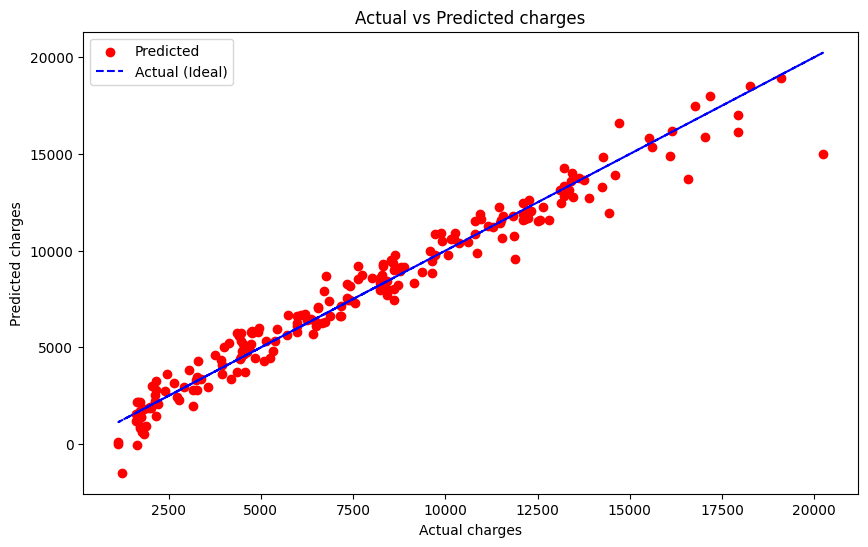

In [98]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color= "red", label="Predicted")
plt.plot(y_test, y_test, color= "blue", linestyle='--', label="Actual (Ideal)")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Actual vs Predicted charges")
plt.legend()
plt.show()

In [101]:
#let us calculate the residual analysis

residuals= y_test- y_pred

residuals

,charges
32,95.865621
110,717.284051
137,-322.044945
89,71.880168
924,-595.989943
...,...
484,455.658283
547,236.371588
111,-1102.966795
516,559.016633


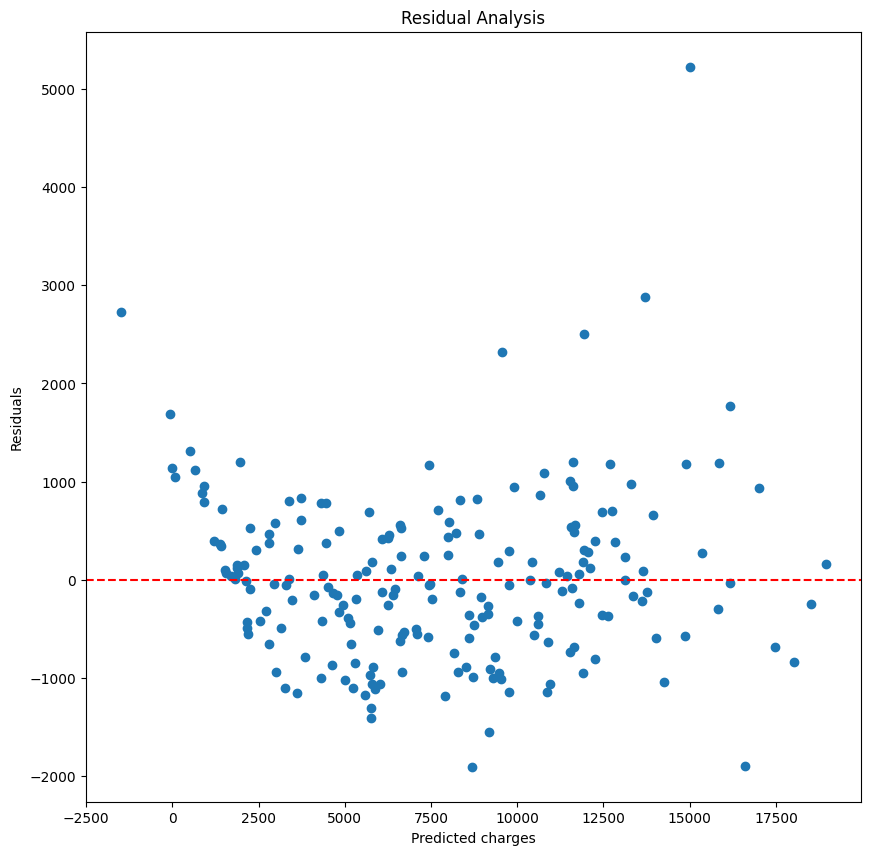

In [102]:
#let's plot this

plt.figure(figsize= (10,10))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color= "red", linestyle= "--")
plt.xlabel("Predicted charges")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

# **Residuals are distributed around zero, although some larger deviations are present. These deviations indicate observations where the model's predictions differ substantially from the actual charges**

In [106]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results['Error'] = results['Actual'] - results['Predicted']
results['Absolute_Error'] = abs(results['Error'])

results.sort_values(
    'Absolute_Error',
    ascending=False
).head(10)


,Actual,Predicted,Error,Absolute_Error
129,20234.85475,15007.226960,5227.627790,5227.627790
146,16586.49771,13708.405681,2878.092029,2878.092029
42,1242.26000,-1481.807646,2724.067646,2724.067646
147,14426.07385,11922.047800,2504.026050,2504.026050
174,11884.04858,9564.143393,2319.905187,2319.905187
43,6770.19250,8676.383951,-1906.191451,1906.191451
182,14711.74380,16608.816887,-1897.073087,1897.073087
178,17929.30337,16155.901787,1773.401583,1773.401583
76,1628.47090,-55.417298,1683.888198,1683.888198
134,7640.30920,9192.118389,-1551.809189,1551.809189


In [107]:
#Now lets calculate the slope and intercept
print("m (slope):",model.coef_)
print("c (intercept):",model.intercept_)

m (slope): [ 4.30630703e+01 -1.24075724e+02 -3.40004856e+00  3.84301619e+01
  2.80582717e+03  6.48241706e-04  5.55731900e-01  3.82484711e-02
  1.30845943e-05 -1.25033179e+03  1.80249183e-05 -4.75920750e+01]
c (intercept): -28671.909137941664


In [108]:
#Now let us create a hypothetical customer information and see what model predicts

new_person = pd.DataFrame([{
    'age': 35,
    'sex': 1,
    'bmi': 27.5,
    'children': 2,
    'smoker': 0,
    'Claim_Amount': 30000,
    'past_consultations': 13,
    'num_of_steps': 880000,
    'Hospital_expenditure': 6000000,
    'NUmber_of_past_hospitalizations': 1,
    'Anual_Salary': 110000000,
    'region': 2
}])

In [110]:
#predict
prediction= model.predict(new_person)
print("Predicted charges:", prediction)

Predicted charges: [7095.64059715]


## Conclusion

In this project, a Linear Regression model was developed to predict annual medical charges using demographic, health, healthcare-utilization, and financial variables.

After performing data cleaning, exploratory data analysis, missing-value treatment, outlier analysis, and categorical encoding, the dataset was divided into training and testing sets. The Linear Regression model was then trained and evaluated using R², MAE, and RMSE.

The model achieved an **R² of 0.9632**, indicating that approximately **96.3% of the variation in medical charges was explained by the features included in the model on the test dataset**. The model achieved an **MAE of 624.12** and an **RMSE of 860.92**, showing that while the model performed well overall, some individual observations had larger prediction errors.

Residual and error analysis showed that the model both overpredicted and underpredicted charges for different individuals. The trained model was also used to estimate the annual medical charges for a hypothetical individual, resulting in a predicted charge of approximately **7,095.64**.

Overall, this project demonstrates the complete workflow of a supervised regression problem, from data exploration and preprocessing to model building, evaluation, error analysis, and prediction.
